# LLM-Augmented Stock Return Prediction — Analysis

**Course:** Artificial Intelligence and Machine Learning, Copenhagen Business School, Summer Term 2026  
**Research question:** ...

| Condition | Description | Method |
|-----------|-------------|--------|
| **B**  | LSTM regressor | LSTM on OHLCV + technicals → log return → direction |
| **B1** | LSTM classifier (single-day) | LSTM with BCELoss, seq_len=1 → direction |
| **B2** | LSTM classifier (sequence) | LSTM with BCELoss, seq_len=20 → direction |
| **L1** | LLM — price only | GPT-5-nano on last 10 days of price data → up/down |
| **L2** | LLM — news only | GPT-5-nano on top-5 article summaries → up/down |
| **L3** | LLM — price + news | GPT-5-nano on price + news → up/down |
| **X1** | XGB regressor (single-day) | XGBoost on current-day features → log return → direction |
| **X2** | XGB regressor (20-day lags) | XGBoost on flattened 20-day features → log return → direction |
| **X3** | XGB classifier (single-day) | XGBoost on current-day features → direction |
| **X4** | XGB classifier (20-day lags) | XGBoost on flattened 20-day features → direction |
| **XN** | XGB classifier + news | X3 + PCA-reduced LLM report embeddings → direction |

In [97]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

ROOT = os.path.join(os.getcwd(), '..')

prices = pd.read_csv(f'{ROOT}/data/processed/prices.csv', parse_dates=['date'], index_col='date')
news   = pd.read_csv(f'{ROOT}/data/processed/news_cache.csv', parse_dates=['date'])

def load_preds(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'].astype(str).str[:10], format='%Y-%m-%d')
    return df

# LSTM conditions
pred_B  = load_preds(f'{ROOT}/results/predictions_B.csv')
pred_B1 = load_preds(f'{ROOT}/results/predictions_B1.csv')
pred_B2 = load_preds(f'{ROOT}/results/predictions_B2.csv')

# LLM conditions
pred_L1 = load_preds(f'{ROOT}/results/predictions_L1.csv')
pred_L2 = load_preds(f'{ROOT}/results/predictions_L2.csv')
pred_L3 = load_preds(f'{ROOT}/results/predictions_L3.csv')

# XGBoost conditions
pred_X1 = load_preds(f'{ROOT}/results/predictions_X1.csv')
pred_X2 = load_preds(f'{ROOT}/results/predictions_X2.csv')
pred_X3 = load_preds(f'{ROOT}/results/predictions_X3.csv')
pred_X4 = load_preds(f'{ROOT}/results/predictions_X4.csv')
pred_XN = load_preds(f'{ROOT}/results/predictions_XN.csv')

for name, df in [('B', pred_B), ('B1', pred_B1), ('B2', pred_B2),
                 ('L1', pred_L1), ('L2', pred_L2), ('L3', pred_L3),
                 ('X1', pred_X1), ('X2', pred_X2), ('X3', pred_X3),
                 ('X4', pred_X4), ('XN', pred_XN)]:
    status = f"{len(df)} days" if df is not None else "not found"
    print(f"pred_{name:2s} : {status}")

pred_B  : 188 days
pred_B1 : 188 days
pred_B2 : 188 days
pred_L1 : 188 days
pred_L2 : 188 days
pred_L3 : 188 days
pred_X1 : 188 days
pred_X2 : 188 days
pred_X3 : 188 days
pred_X4 : 188 days
pred_XN : 188 days


---
## Section 1 — Data Overview

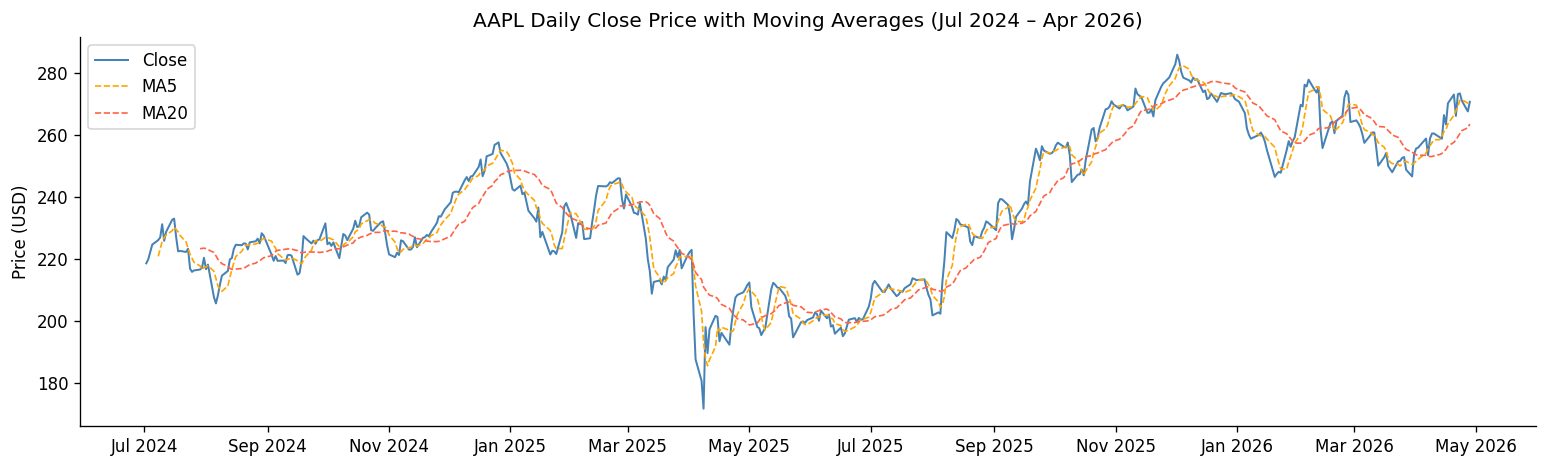

In [98]:
# ── AAPL price history: close + MA5 + MA20 ───────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(prices.index, prices['close'], color='steelblue', lw=1.2, label='Close')
ax.plot(prices.index, prices['ma5'],  color='orange',    lw=1.0, ls='--', label='MA5')
ax.plot(prices.index, prices['ma20'], color='tomato',    lw=1.0, ls='--', label='MA20')

ax.set_title('AAPL Daily Close Price with Moving Averages (Jul 2024 – Apr 2026)')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.legend()
fig.tight_layout()
plt.savefig(f'{ROOT}/results/figures/price_history.png', bbox_inches='tight')
plt.show()

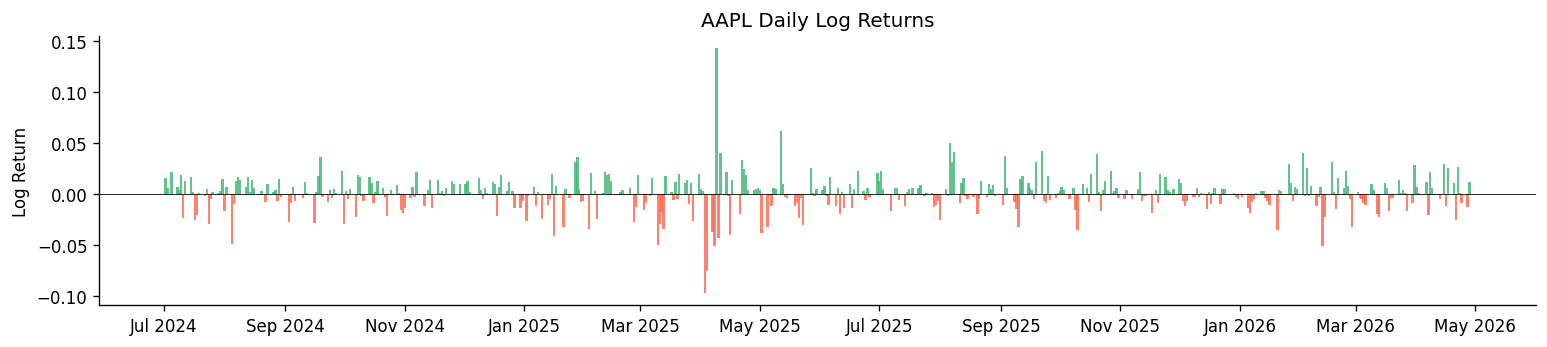

In [99]:
# ── Daily log returns bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3))

colors = ['tomato' if r < 0 else 'mediumseagreen' for r in prices['daily_log_return']]
ax.bar(prices.index, prices['daily_log_return'], color=colors, width=1.2, alpha=0.8)
ax.axhline(0, color='black', lw=0.5)

ax.set_title('AAPL Daily Log Returns')
ax.set_ylabel('Log Return')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.tight_layout()
plt.savefig(f'{ROOT}/results/figures/log_returns.png', bbox_inches='tight')
plt.show()

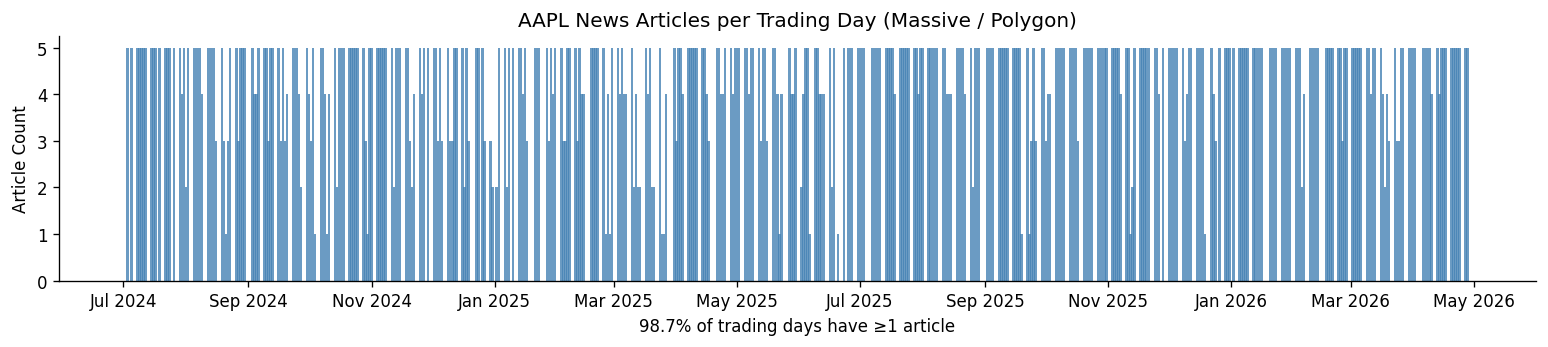

In [100]:
# ── News coverage: articles per trading day ───────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3))

news_plot = news.copy()
news_plot['date'] = pd.to_datetime(news_plot['date'])
news_plot = news_plot.set_index('date').sort_index()

ax.bar(news_plot.index, news_plot['article_count'], color='steelblue', width=1.2, alpha=0.8)
ax.set_title('AAPL News Articles per Trading Day (Massive / Polygon)')
ax.set_ylabel('Article Count')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

pct_covered = 100 * (news_plot['article_count'] > 0).mean()
ax.set_xlabel(f'{pct_covered:.1f}% of trading days have ≥1 article')
fig.tight_layout()
plt.savefig(f'{ROOT}/results/figures/news_coverage.png', bbox_inches='tight')
plt.show()

---
## Section 2 — Walk-Forward Prediction Charts

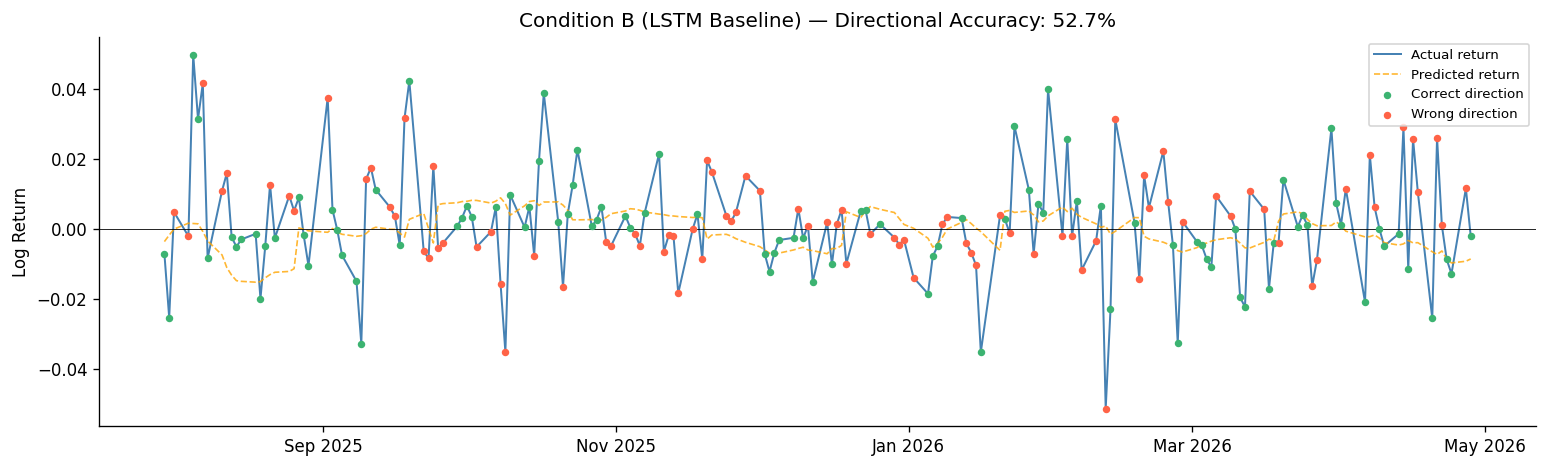

In [101]:
# ── Condition B: actual vs predicted log return ───────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(pred_B['date'], pred_B['actual_return'],    color='steelblue', lw=1.2, label='Actual return')
ax.plot(pred_B['date'], pred_B['predicted_return'], color='orange',    lw=1.0, ls='--', alpha=0.8, label='Predicted return')

correct = pred_B['actual_direction'] == pred_B['predicted_direction']
ax.scatter(pred_B.loc[correct, 'date'],  pred_B.loc[correct, 'actual_return'],
           color='mediumseagreen', s=12, zorder=3, label='Correct direction')
ax.scatter(pred_B.loc[~correct, 'date'], pred_B.loc[~correct, 'actual_return'],
           color='tomato',         s=12, zorder=3, label='Wrong direction')

acc = correct.mean()
ax.set_title(f'Condition B (LSTM Baseline) — Directional Accuracy: {acc:.1%}')
ax.set_ylabel('Log Return')
ax.axhline(0, color='black', lw=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig(f'{ROOT}/results/figures/pred_B.png', bbox_inches='tight')
plt.show()

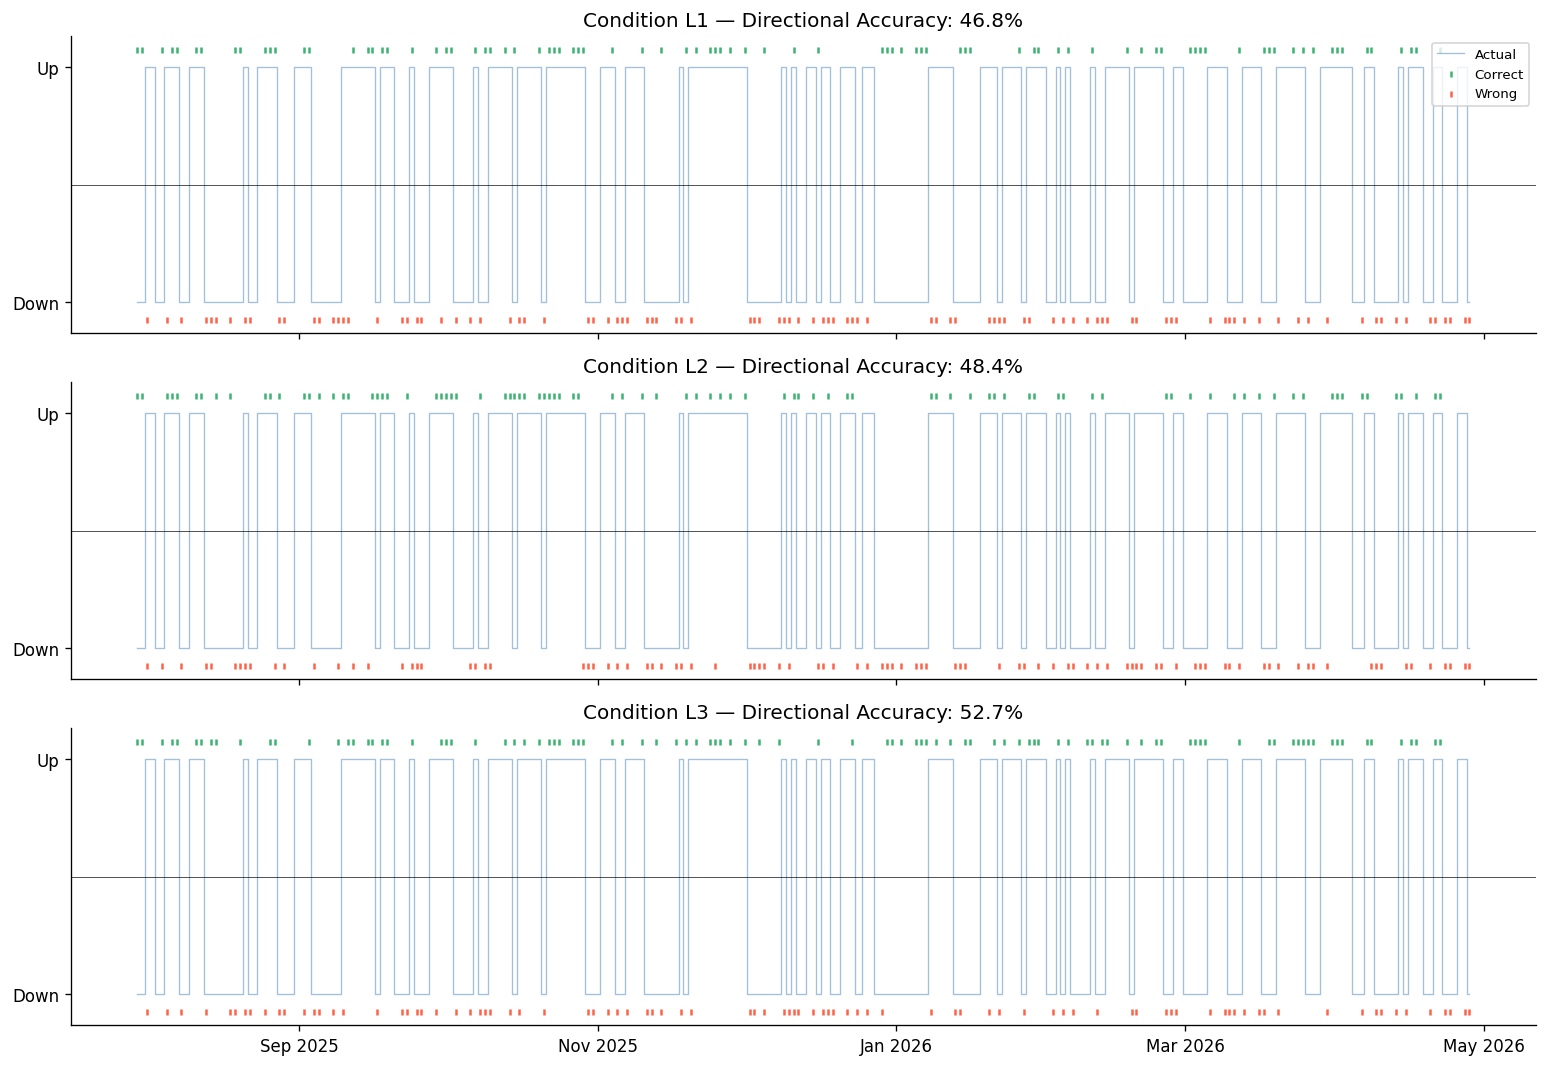

In [102]:
def plot_llm_condition(pred_df, label, ax):
    """Plot LLM up/down predictions with correct (green) / wrong (red) markers."""
    pred_df = pred_df.dropna(subset=['actual_direction', 'predicted_direction'])
    correct  = pred_df['actual_direction'] == pred_df['predicted_direction']
    acc      = correct.mean()

    # Actual direction as +1 / -1 step line
    actual_dir = pred_df['actual_direction'].map({1: 1, 0: -1})
    ax.step(pred_df['date'], actual_dir, where='mid', color='steelblue', lw=0.8, alpha=0.5, label='Actual')

    ax.scatter(pred_df.loc[correct, 'date'],  [1.15] * correct.sum(),
               color='mediumseagreen', s=14, marker='|', label='Correct')
    ax.scatter(pred_df.loc[~correct, 'date'], [-1.15] * (~correct).sum(),
               color='tomato',         s=14, marker='|', label='Wrong')

    ax.set_title(f'Condition {label} — Directional Accuracy: {acc:.1%}')
    ax.set_yticks([-1, 1]); ax.set_yticklabels(['Down', 'Up'])
    ax.axhline(0, color='black', lw=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    return acc

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, (df, label) in zip(axes, [(pred_L1, 'L1'), (pred_L2, 'L2'), (pred_L3, 'L3')]):
    plot_llm_condition(df, label, ax)

axes[0].legend(fontsize=8, loc='upper right')
fig.tight_layout()
plt.savefig(f'{ROOT}/results/figures/pred_LLM.png', bbox_inches='tight')
plt.show()

---
## Section 2b — XGBoost & LSTM Classifier Predictions

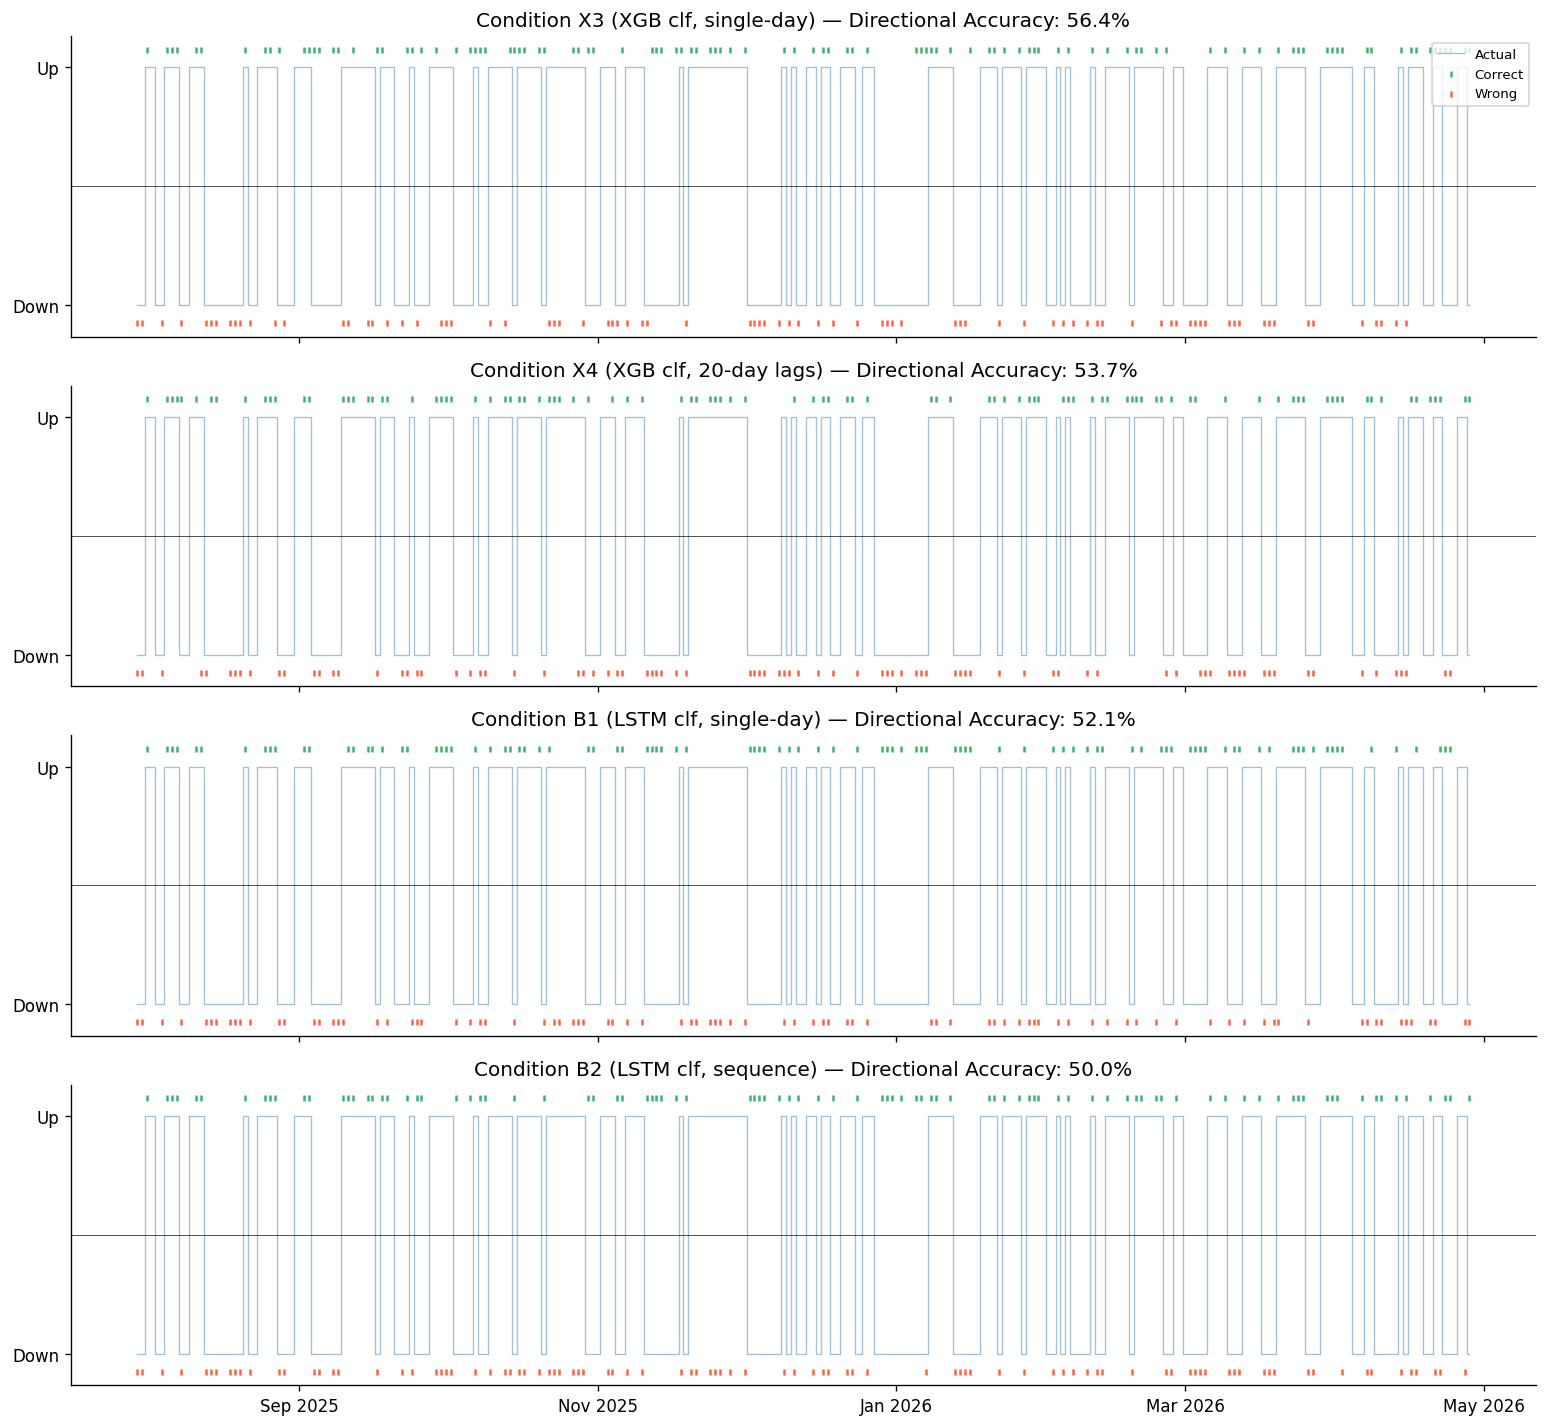

In [103]:
def plot_clf_condition(pred_df, label, ax):
    """Plot binary classifier predictions with correct/wrong markers."""
    pred_df = pred_df.dropna(subset=['actual_direction', 'predicted_direction'])
    correct  = pred_df['actual_direction'] == pred_df['predicted_direction']
    acc      = correct.mean()

    actual_dir = pred_df['actual_direction'].map({1: 1, 0: -1})
    ax.step(pred_df['date'], actual_dir, where='mid', color='steelblue', lw=0.8, alpha=0.5, label='Actual')

    ax.scatter(pred_df.loc[correct,  'date'], [ 1.15] * correct.sum(),
               color='mediumseagreen', s=14, marker='|', label='Correct')
    ax.scatter(pred_df.loc[~correct, 'date'], [-1.15] * (~correct).sum(),
               color='tomato',         s=14, marker='|', label='Wrong')

    ax.set_title(f'Condition {label} — Directional Accuracy: {acc:.1%}')
    ax.set_yticks([-1, 1]); ax.set_yticklabels(['Down', 'Up'])
    ax.axhline(0, color='black', lw=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# ── XGBoost classifiers ───────────────────────────────────────────────────────
clf_conditions = [(pred_X3, 'X3 (XGB clf, single-day)'),
                  (pred_X4, 'X4 (XGB clf, 20-day lags)'),
                  (pred_B1, 'B1 (LSTM clf, single-day)'),
                  (pred_B2, 'B2 (LSTM clf, sequence)')]
clf_conditions = [(df, lbl) for df, lbl in clf_conditions if df is not None]

fig, axes = plt.subplots(len(clf_conditions), 1, figsize=(13, 3 * len(clf_conditions)), sharex=True)
if len(clf_conditions) == 1:
    axes = [axes]

for ax, (df, label) in zip(axes, clf_conditions):
    plot_clf_condition(df, label, ax)

axes[0].legend(fontsize=8, loc='upper right')
fig.tight_layout()
plt.savefig(f'{ROOT}/results/figures/pred_classifiers.png', bbox_inches='tight')
plt.show()

---
## Section 3 — Metrics Summary

In [104]:
# ── Helper functions ──────────────────────────────────────────────────────────
def dir_accuracy(pred_df, act_col='actual_direction', pred_col='predicted_direction'):
    df = pred_df.dropna(subset=[act_col, pred_col])
    return (df[act_col] == df[pred_col]).mean()

def conf_weighted_accuracy(pred_df, threshold=0.7):
    df = pred_df.dropna(subset=['actual_direction', 'predicted_direction', 'confidence'])
    high = df[df['confidence'] >= threshold]
    if len(high) == 0:
        return float('nan'), 0
    return (high['actual_direction'] == high['predicted_direction']).mean(), len(high)

def regression_metrics(pred_df):
    actual = pred_df['actual_return'].values
    pred   = pred_df['predicted_return'].values
    mae    = np.mean(np.abs(actual - pred))
    rmse   = np.sqrt(np.mean((actual - pred) ** 2))
    return mae, rmse

# ── Unified comparison table ──────────────────────────────────────────────────
rows = []

# LSTM regressor (B) — has predicted_return
mae_B, rmse_B = regression_metrics(pred_B)
rows.append({'Condition': 'B  — LSTM regressor',       'N': len(pred_B),
             'Dir. Acc': f"{dir_accuracy(pred_B):.1%}", 'MAE': f"{mae_B:.5f}", 'RMSE': f"{rmse_B:.5f}"})

# LSTM classifiers (B1, B2) — direction only
for df, label in [(pred_B1, 'B1 — LSTM clf (single-day)'), (pred_B2, 'B2 — LSTM clf (sequence)')]:
    if df is not None:
        rows.append({'Condition': label, 'N': len(df),
                     'Dir. Acc': f"{dir_accuracy(df):.1%}", 'MAE': '—', 'RMSE': '—'})

# LLM conditions — direction + confidence
for df, label in [(pred_L1, 'L1 — LLM price only'), (pred_L2, 'L2 — LLM news only'), (pred_L3, 'L3 — LLM price+news')]:
    cw_acc, n_high = conf_weighted_accuracy(df)
    rows.append({'Condition': label, 'N': len(df.dropna(subset=['actual_direction'])),
                 'Dir. Acc': f"{dir_accuracy(df):.1%}", 'MAE': '—', 'RMSE': '—'})

# XGBoost regressors (X1, X2) — have predicted_return
for df, label in [(pred_X1, 'X1 — XGB regressor (single-day)'), (pred_X2, 'X2 — XGB regressor (20-day lags)')]:
    if df is not None:
        mae, rmse = regression_metrics(df)
        rows.append({'Condition': label, 'N': len(df),
                     'Dir. Acc': f"{dir_accuracy(df):.1%}", 'MAE': f"{mae:.5f}", 'RMSE': f"{rmse:.5f}"})

# XGBoost classifiers (X3, X4, XN) — direction only
for df, label in [(pred_X3, 'X3 — XGB clf (single-day)'), (pred_X4, 'X4 — XGB clf (20-day lags)'),
                  (pred_XN, 'XN — XGB clf + news')]:
    if df is not None:
        rows.append({'Condition': label, 'N': len(df),
                     'Dir. Acc': f"{dir_accuracy(df):.1%}", 'MAE': '—', 'RMSE': '—'})

summary = pd.DataFrame(rows).set_index('Condition')
print('Random baseline: 50.0%')
summary

Random baseline: 50.0%


,N,Dir. Acc,MAE,RMSE
Condition,,,,
B — LSTM regressor,188,52.7%,0.01148,0.01544
B1 — LSTM clf (single-day),188,52.1%,—,—
B2 — LSTM clf (sequence),188,50.0%,—,—
L1 — LLM price only,188,46.8%,—,—
L2 — LLM news only,188,48.4%,—,—
L3 — LLM price+news,188,52.7%,—,—
X1 — XGB regressor (single-day),188,45.2%,0.01061,0.01490
X2 — XGB regressor (20-day lags),188,46.8%,0.01057,0.01495
X3 — XGB clf (single-day),188,56.4%,—,—


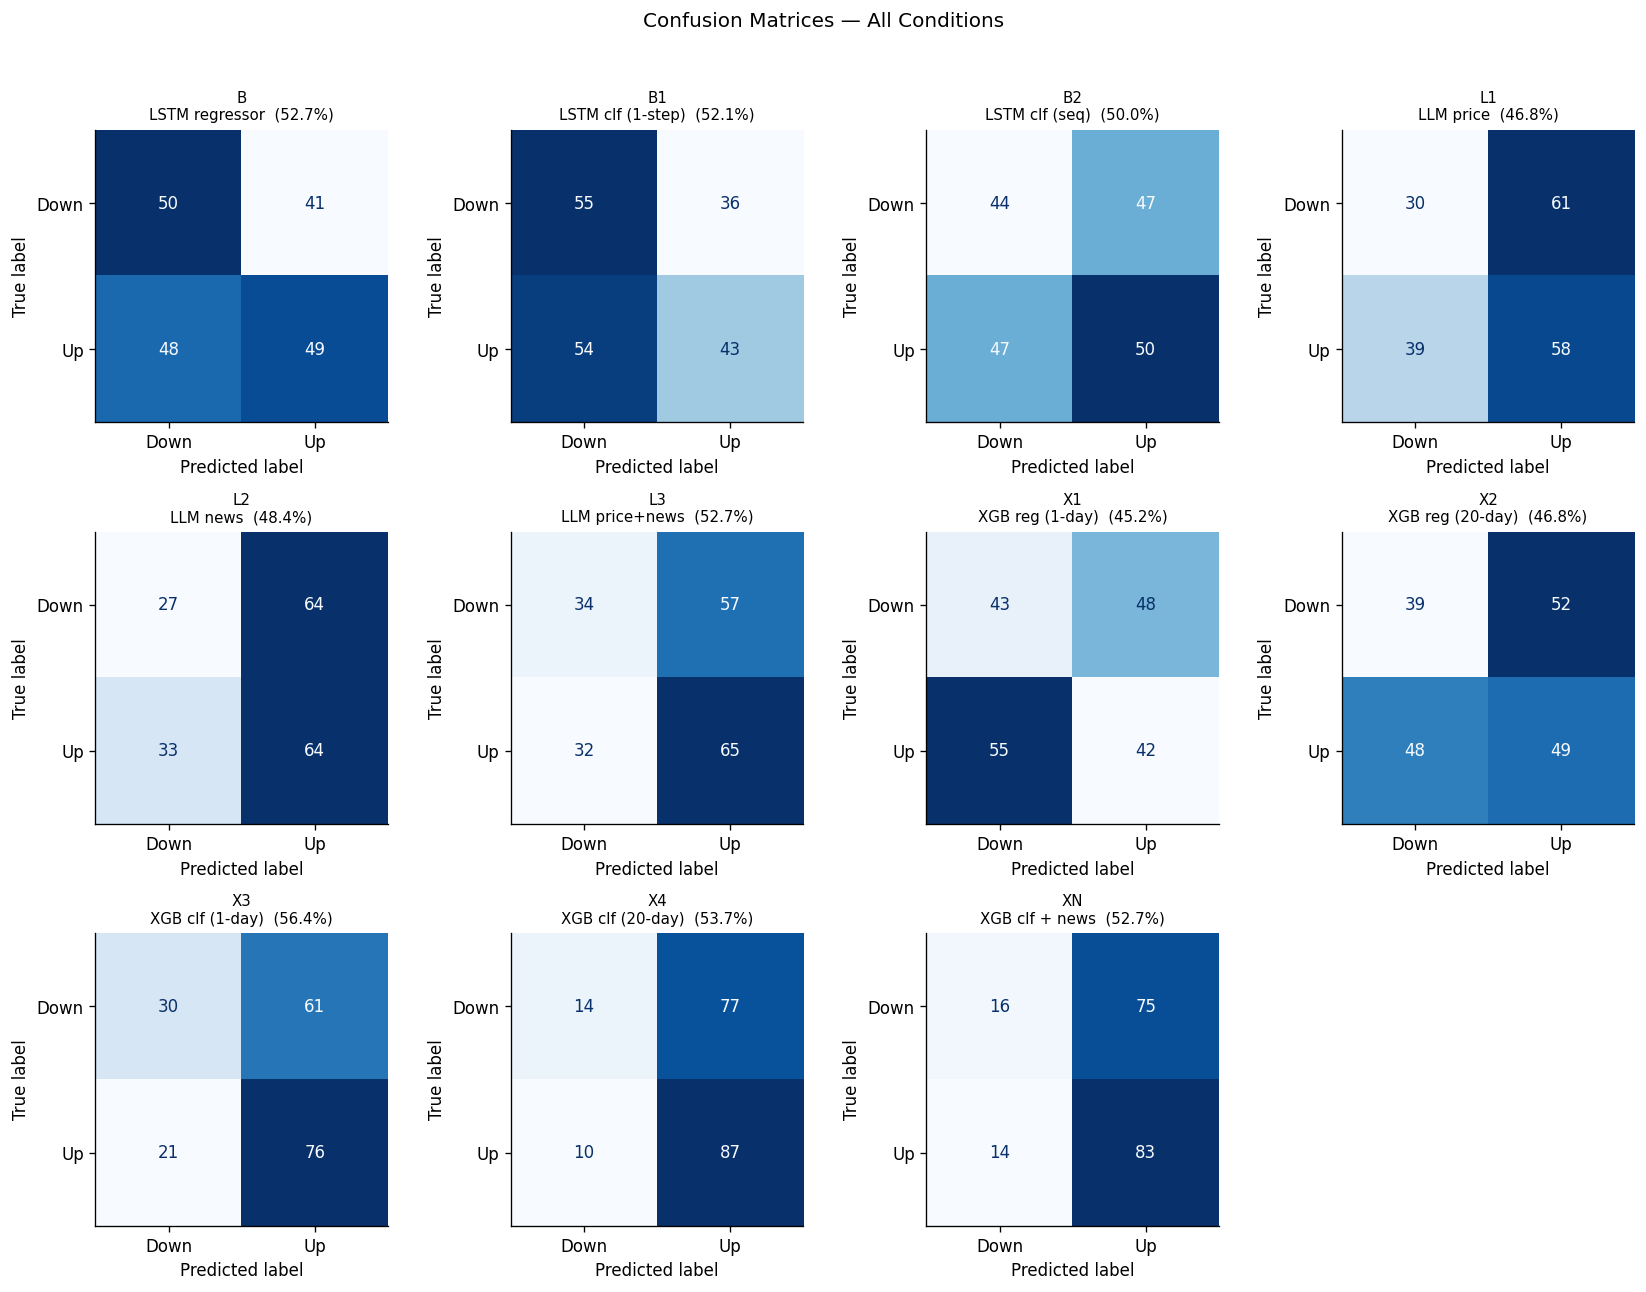

In [105]:
# ── Confusion matrices for all conditions ─────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_clf_conditions = [
    (pred_B,  'B\nLSTM regressor'),
    (pred_B1, 'B1\nLSTM clf (1-step)'),
    (pred_B2, 'B2\nLSTM clf (seq)'),
    (pred_L1, 'L1\nLLM price'),
    (pred_L2, 'L2\nLLM news'),
    (pred_L3, 'L3\nLLM price+news'),
    (pred_X1, 'X1\nXGB reg (1-day)'),
    (pred_X2, 'X2\nXGB reg (20-day)'),
    (pred_X3, 'X3\nXGB clf (1-day)'),
    (pred_X4, 'X4\nXGB clf (20-day)'),
    (pred_XN, 'XN\nXGB clf + news'),
]

n_cols = 4
n_rows = (len(all_clf_conditions) + n_cols - 1) // n_cols  # 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))

for i, (df, label) in enumerate(all_clf_conditions):
    ax = axes[i // n_cols, i % n_cols]
    df_clean = df.dropna(subset=['actual_direction', 'predicted_direction'])
    cm = confusion_matrix(df_clean['actual_direction'].astype(int),
                          df_clean['predicted_direction'].astype(int))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = (df_clean['actual_direction'] == df_clean['predicted_direction']).mean()
    ax.set_title(f'{label}  ({acc:.1%})', fontsize=9)

for j in range(len(all_clf_conditions), n_rows * n_cols):
    axes[j // n_cols, j % n_cols].set_visible(False)

fig.suptitle('Confusion Matrices — All Conditions', y=1.02)
fig.tight_layout()
plt.savefig(f'{ROOT}/results/figures/confusion_matrices.png', bbox_inches='tight')
plt.show()

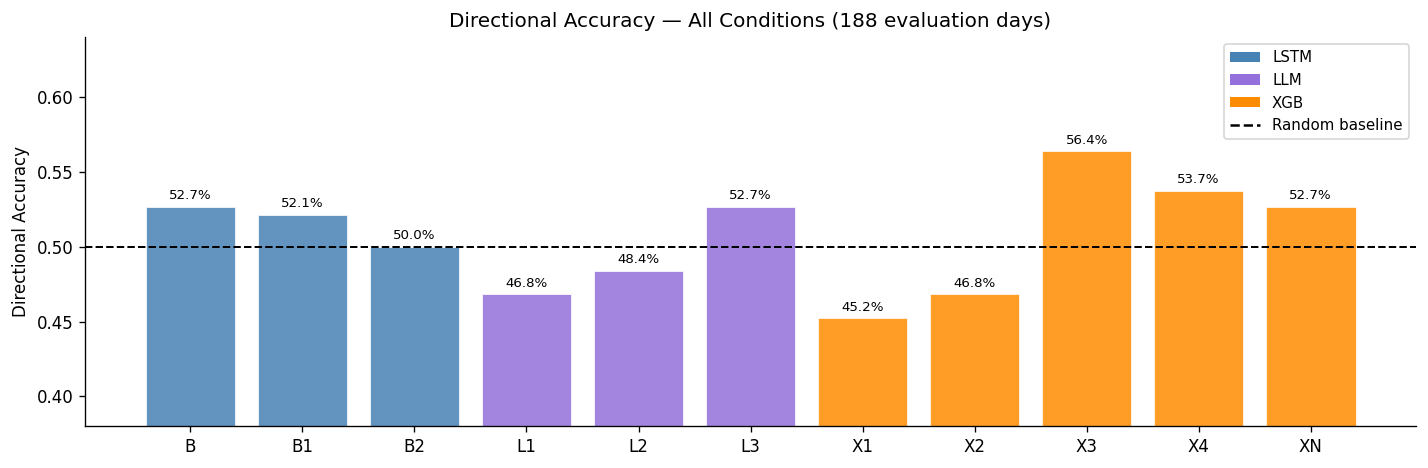

In [106]:
# ── Leaderboard bar chart — all conditions ────────────────────────────────────
all_conditions = [
    (pred_B,  'B',  'LSTM'),
    (pred_B1, 'B1', 'LSTM'),
    (pred_B2, 'B2', 'LSTM'),
    (pred_L1, 'L1', 'LLM'),
    (pred_L2, 'L2', 'LLM'),
    (pred_L3, 'L3', 'LLM'),
    (pred_X1, 'X1', 'XGB'),
    (pred_X2, 'X2', 'XGB'),
    (pred_X3, 'X3', 'XGB'),
    (pred_X4, 'X4', 'XGB'),
    (pred_XN, 'XN', 'XGB'),
]
all_conditions = [(df, lbl, grp) for df, lbl, grp in all_conditions if df is not None]

labels  = [lbl for _, lbl, _ in all_conditions]
accs    = [dir_accuracy(df) for df, _, _ in all_conditions]
groups  = [grp for _, _, grp in all_conditions]

color_map = {'LSTM': 'steelblue', 'LLM': 'mediumpurple', 'XGB': 'darkorange'}
colors = [color_map[g] for g in groups]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(labels, accs, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axhline(0.5, color='black', lw=1.2, ls='--', label='Random baseline (50%)')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g) for g, c in color_map.items()]
legend_elements.append(plt.Line2D([0], [0], color='black', ls='--', label='Random baseline'))
ax.legend(handles=legend_elements, fontsize=9)

ax.set_ylim(0.38, 0.64)
ax.set_ylabel('Directional Accuracy')
ax.set_title('Directional Accuracy — All Conditions (188 evaluation days)')
fig.tight_layout()
plt.savefig(f'{ROOT}/results/figures/leaderboard.png', bbox_inches='tight')
plt.show()

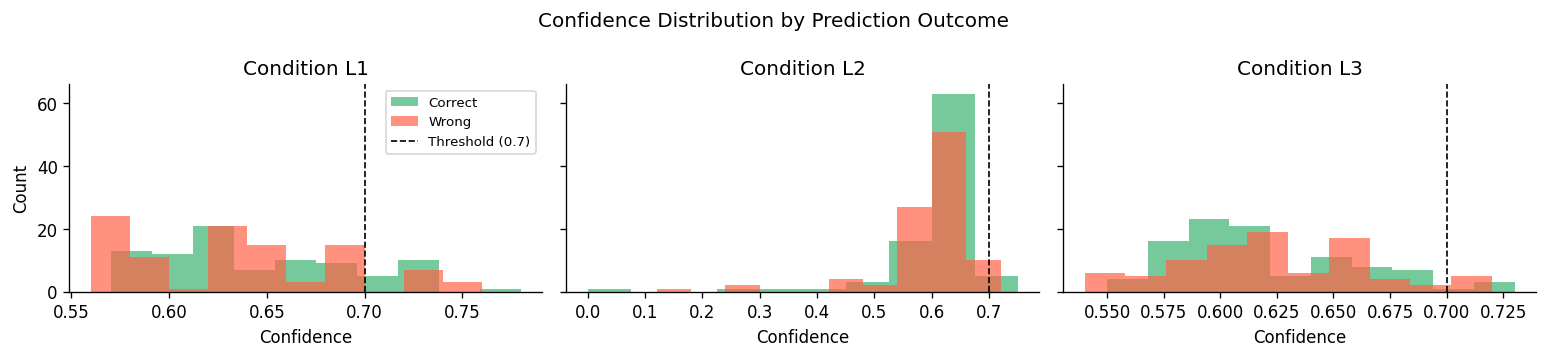

In [107]:
# ── Confidence distribution for LLM conditions ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)

for ax, (df, label) in zip(axes, [(pred_L1, 'L1'), (pred_L2, 'L2'), (pred_L3, 'L3')]):
    df_c = df.dropna(subset=['confidence', 'actual_direction', 'predicted_direction'])
    correct = df_c['actual_direction'] == df_c['predicted_direction']
    ax.hist(df_c.loc[correct,  'confidence'], bins=10, alpha=0.7, color='mediumseagreen', label='Correct')
    ax.hist(df_c.loc[~correct, 'confidence'], bins=10, alpha=0.7, color='tomato',         label='Wrong')
    ax.axvline(0.7, color='black', ls='--', lw=1, label='Threshold (0.7)')
    ax.set_title(f'Condition {label}')
    ax.set_xlabel('Confidence')

axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)
fig.suptitle('Confidence Distribution by Prediction Outcome')
fig.tight_layout()
plt.savefig(f'{ROOT}/results/figures/confidence_dist.png', bbox_inches='tight')
plt.show()

In [108]:
# ── MAE and RMSE for condition B ──────────────────────────────────────────────
print('Condition B — Regression metrics')
print(f'  MAE : {mae_B:.6f}')
print(f'  RMSE: {rmse_B:.6f}')
print(f'  (Naive baseline RMSE — std of actual returns: {pred_B["actual_return"].std():.6f})')

Condition B — Regression metrics
  MAE : 0.011478
  RMSE: 0.015437
  (Naive baseline RMSE — std of actual returns: 0.014771)


---
## Section 4 — Discussion

### 4.1 Summary of results

| Condition | Dir. Accuracy | Pred. "up" rate |
|-----------|:---:|:---:|
| B — LSTM regressor | 52.7% | 47.9% |
| B1 — LSTM clf (single-day) | 52.1% | 42.0% |
| B2 — LSTM clf (sequence) | 50.0% | 51.6% |
| L1 — LLM price only | 46.8% | 63.3% |
| L2 — LLM news only | 48.4% | 68.1% |
| L3 — LLM price+news | 52.7% | 64.9% |
| X1 — XGB regressor (single-day) | 45.2% | 47.9% |
| X2 — XGB regressor (20-day lags) | 46.8% | 53.7% |
| **X3 — XGB clf (single-day)** | **56.4%** | 72.9% |
| X4 — XGB clf (20-day lags) | 53.7% | 87.2% |
| XN — XGB clf + news | 52.7% | 84.0% |

Random baseline: **50.0%**. Actual market up-rate over evaluation period: **51.6%**.

X3 records the highest directional accuracy (56.4%), but as discussed below, this is partly attributable to upward prediction bias. No condition achieves a decisive improvement over the random baseline.

### 4.2 The upward-bias problem

A recurring pattern across conditions is a systematic tendency to over-predict "up." The effect is sharpest for XGBoost classifiers and LLM conditions:

- **LLM conditions** predict "up" on 63–68% of evaluation days, despite the market rising on only 51.6%.
- **XGB classifiers** are even more extreme: X3 predicts "up" on 72.9% of days, X4 on 87.2%, and XN on 84.0%.
- **LSTM conditions** are the exception: B predicts "up" on 47.9% (slightly contrarian), B1 on 42.0%, and B2 on 51.6% — nearly matching the actual up-rate.

For the LLM conditions, the bias plausibly reflects the bullish tone of financial text on which the model was trained. For XGBoost classifiers, the likely explanation is class imbalance within rolling training windows: during a broadly upward-trending market, "up" days dominate training observations and the classifier defaults toward the majority class. B2's near-perfect calibration (51.6% predicted up-rate vs 51.6% actual) may reflect the sequence model learning the unconditional base rate rather than any directional signal.

The upward bias matters for interpretation: any accuracy above 51.6% can be partially achieved by predicting "up" every single day. X3's 56.4% accuracy with a 72.9% "up" rate reflects genuine directional skill only to the degree it exceeds what naive upward bias would produce.

### 4.3 Regression vs classification framing (XGBoost)

The most striking finding for the XGBoost conditions is the large gap between regressors and classifiers:

| | Single-day features | 20-day lag features |
|---|:---:|:---:|
| Regressor (predict log return → derive direction) | X1: 45.2% | X2: 46.8% |
| Classifier (predict direction directly) | X3: 56.4% | X4: 53.7% |

Both regressors fall **below** the random baseline, while both classifiers exceed it. The regression path introduces an extra difficulty: the model must estimate the sign of a near-zero continuous value (median absolute log return ≈ 0.01), amplifying noise. Training the classifier directly on the binary direction target avoids this intermediate step and allows the model to focus on the boundary between up and down days.

The lag-window extension (X3 → X4) does not clearly help: X4 trails X3 by 2.7 pp. Flattening 20 days of features into a 180-dimensional vector likely introduces sparsity issues given the 250-day rolling training windows, reducing the benefit of the additional historical context.

### 4.4 Does news help?

Neither the LLM conditions nor the XGBoost classifier benefit from news.

**LLM:** L3 (price+news, 52.7%) outperforms L1 (price only, 46.8%) by 6 pp, but this improvement is better explained by L3's slightly reduced upward bias (64.9% vs 63.3%) partially compensating when the combined prompt moderates the model's bullish prior, rather than by genuine news signal extraction. L2 (news only, 48.4%) does not outperform L1, and its confidence-weighted accuracy (30.0% at ≥0.7 confidence, n=10) falls below random — suggesting the model is most confident precisely when it is most biased toward bullish calls on ultimately bearish days.

**XGBoost:** XN (X3 + PCA news embeddings, 52.7%) falls 3.7 pp short of X3 (56.4%) while simultaneously increasing the up-bias from 72.9% to 84.0%. Adding structured news embeddings actively hurts the XGBoost classifier — the PCA-reduced vectors appear to add noise and reinforce the classifier's majority-class tendency rather than contributing signal.

In both model families, news features as currently implemented do not add reliable directional information over price data alone.

### 4.5 LSTM classifier variants

Reframing the LSTM task from regression (B) to binary classification (B1, B2) does not yield improvement:

- **B1** (seq_len=1, single-day): 52.1% — marginally below B (52.7%), with a low predicted up-rate (42.0%), suggesting the single-timestep classifier learns a contrarian bias.
- **B2** (seq_len=20, full sequence): 50.0% — exactly random, with a predicted up-rate (51.6%) that mirrors the market's actual rate. The sequence classifier appears to learn the unconditional base rate and little else.

The original LSTM regressor (B) outperforms both classifier variants. The directional signal in the regression target (log return magnitude and sign) may provide a richer training objective than a hard binary label at this dataset size, making the regression-then-sign approach preferable here.

### 4.6 Limitations

- **Sample size:** 188 evaluation days is a short window. A 5 pp accuracy difference corresponds to ~9 additional correct calls — well within sampling noise. No results reported here are statistically significant at conventional levels.
- **Upward-bias confounding:** for conditions with a high predicted up-rate (X3, X4, XN), directional accuracy overstates genuine skill. Precision/recall broken down by class, or a skill score corrected for base rate, would provide a cleaner comparison.
- **Non-stationarity:** the evaluation period (Jul 2025 – Apr 2026) spans varying market regimes. Performance may differ materially across sub-periods such as the tariff-driven volatility of early 2026.
- **News quality:** the Massive API descriptions are short (1–3 sentences). Richer article bodies, earnings transcripts, or SEC filings might carry stronger signal for L2, L3, and XN.
- **LLM temperature:** `gpt-5-nano` does not support `temperature=0`, so LLM predictions carry sampling variance. Running multiple passes per day and aggregating would reduce this but increases API cost.
- **LSTM capacity:** the 250-day rolling window and seq_len=20 leave limited training signal for a 2-layer LSTM. A simpler model (e.g. logistic regression on lagged returns) might perform comparably with lower variance.
- **Sentiment features unused:** the `aapl_sentiments` and `sentiment_score` columns in `news_cache.csv` were collected but not used in any model in this version. Incorporating Massive's per-article AAPL sentiment as a structured feature — rather than raw text — is a natural next step.